# Router-Only Salvage on v3: `Clustering_V0_Full_k2` + `Clustering_Backbone54_k2`
## Same frozen protocol, canonical eval set, global baselines added

Follow-up to `derived_8.4-ece-router-salvage-1.0`, repeated on the canonical
`derived_8.4_ece_v3` split (150 rows, 30-day warmup scaffold, strict native-NaN
SMAP, MODIS NDVI fallback). Two single-regime global baselines
(`Global_Single_54`, `Global_Single_50`, `policy=direct`) are reported as
reference rows. Experts and baselines are frozen (fit on WA `trainval` only);
routing policies are inference-time label overrides; ECE targets are used for
evaluation only; the margin threshold comes from WA `trainval` only and falls
back to the `Global_Single_54` expert.


## 1. Load the versioned experiment implementation
The notebook imports the tracked runner instead of duplicating logic, so results
reproduce from a clean checkout. Paths resolve from the repository root.


In [1]:
from pathlib import Path
import importlib.util
import sys

cur = Path.cwd().resolve()
while cur != cur.parent:
    if (cur / "data" / "splits").exists() and (cur / "notebooks").exists():
        PROJECT_ROOT = cur
        break
    cur = cur.parent

EXP_DIR = PROJECT_ROOT / "notebooks/experiment/derived_8.4-ece-router-salvage-1.1"
sys.path.insert(0, str(EXP_DIR))
RUNNER_PATH = EXP_DIR / "run_salvage.py"
spec = importlib.util.spec_from_file_location("router_salvage_v3", RUNNER_PATH)
salvage = importlib.util.module_from_spec(spec)
spec.loader.exec_module(salvage)
config = salvage.load_configuration()
print(f"Experiment: {config['experiment']['name']}")
print(f"Families: {config['families']}")
print(f"Baselines: {config['baselines']}")
print(f"Policies: {config['policies']}")
print(f"Seeds: {config['seeds']}")
print(f"Constraint: {config['experiment']['constraint']}")


Experiment: derived_8.4-ece-router-salvage-1.1
Families: ['Clustering_V0_Full_k2', 'Clustering_Backbone54_k2']
Baselines: ['Global_Single_54', 'Global_Single_50']
Policies: ['as_routed', 'c0_only', 'c1_only', 'gapi_transplant', 'dynamic_transplant', 'seasonal', 'margin_fallback', 'direct']
Seeds: [42, 7, 13, 101, 123]
Constraint: ECE strictly unseen; experts fit on WA trainval only; routing is the only inference-time change.


## 2. Run the salvage on v3
Fits routers, experts, and baselines on WA `trainval` only, then scores the v3
ECE split under each routing policy plus the two `direct` baselines. Per-seed
checkpoints resume, so re-execution is fast when artifacts exist. From a clean
checkout this cell trains (documented timeout 3600s, CPU).


In [2]:
salvage.main([])  # [] = defaults; avoids parsing the kernel's argv


WA margin p5: v0=1.9560 backbone=1.5481
train_rows=14608 ece_v3_rows=150 families=['Clustering_V0_Full_k2', 'Clustering_Backbone54_k2'] baselines=['Global_Single_54', 'Global_Single_50']
seed=42 resumed (16 rows)
seed=7 resumed (16 rows)
seed=13 resumed (16 rows)
seed=101 resumed (16 rows)
seed=123 resumed (16 rows)



ROUTER SALVAGE SUMMARY (mean over seeds)
                  family ece_input             policy  rmse_mean  rmse_std  mae_mean  bias_mean  ubrmse_mean    r2_mean  pearson_mean  rmse_change_vs_as_routed
   Clustering_V0_Full_k2        v3          as_routed   0.164867  0.001896  0.138543   0.118080     0.115050 -11.280409     -0.666047                  0.000000
   Clustering_V0_Full_k2        v3            c0_only   0.059286  0.000882  0.051448   0.030983     0.050515  -0.588128      0.107078                 -0.105581
   Clustering_V0_Full_k2        v3            c1_only   0.191068  0.002693  0.184136   0.184136     0.050992 -15.494723     -0.481025                  0.026201
   Clustering_V0_Full_k2        v3    gapi_transplant   0.059286  0.000882  0.051448   0.030983     0.050515  -0.588128      0.107078                 -0.105581
   Clustering_V0_Full_k2        v3 dynamic_transplant   0.059286  0.000882  0.051448   0.030983     0.050515  -0.588128      0.107078                 -0.10558

## 3. Policy comparison against global baselines
Pooled RMSE / bias per policy on v3, with the two single-regime baselines drawn
as reference lines. `rmse_change_vs_as_routed` is NaN for baselines (no
`as_routed` exists) — compare them directly by `rmse_mean`.


In [3]:
import json
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

summary = pd.read_csv(EXP_DIR / "summary.csv")
seed_metrics = pd.read_csv(EXP_DIR / "seed_metrics.csv")
with (EXP_DIR / "routing_audit.json").open(encoding="utf-8") as f:
    audit = json.load(f)
print(f"WA margin thresholds: {audit['wa_thresholds']}")
print(summary.to_string(index=False))

regime_policies = [p for p in config["policies"] if p != "direct"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (family, sub) in zip(axes, summary.groupby("family")):
    if family in config["baselines"]:
        continue
    panel = sub.set_index("policy").reindex(regime_policies)
    ax.bar(panel.index, panel["rmse_mean"], yerr=panel["rmse_std"], capsize=3)
    for base in config["baselines"]:
        row = summary.query("family == @base and policy == 'direct'")
        if not row.empty:
            ax.axhline(float(row["rmse_mean"].iloc[0]), linestyle="--",
                       label=f"{base} direct")
    ax.set_title(f"{family} (v3 ECE)")
    ax.set_ylabel("pooled RMSE (m3/m3)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
fig.tight_layout()
(EXP_DIR / "figures").mkdir(exist_ok=True)
fig.savefig(EXP_DIR / "figures" / "policy_rmse_by_family_v3.png", dpi=150)
print("Saved figures/policy_rmse_by_family_v3.png")


WA margin thresholds: {'v0': 1.9559823212899237, 'backbone': 1.5480887296641908}
                  family ece_input             policy  rmse_mean  rmse_std  mae_mean  bias_mean  ubrmse_mean    r2_mean  pearson_mean  rmse_change_vs_as_routed
   Clustering_V0_Full_k2        v3          as_routed   0.164867  0.001896  0.138543   0.118080     0.115050 -11.280409     -0.666047                  0.000000
   Clustering_V0_Full_k2        v3            c0_only   0.059286  0.000882  0.051448   0.030983     0.050515  -0.588128      0.107078                 -0.105581
   Clustering_V0_Full_k2        v3            c1_only   0.191068  0.002693  0.184136   0.184136     0.050992 -15.494723     -0.481025                  0.026201
   Clustering_V0_Full_k2        v3    gapi_transplant   0.059286  0.000882  0.051448   0.030983     0.050515  -0.588128      0.107078                 -0.105581
   Clustering_V0_Full_k2        v3 dynamic_transplant   0.059286  0.000882  0.051448   0.030983     0.050515  -0.588128

Saved figures/policy_rmse_by_family_v3.png


## 4. Station-level verdict on v3
Compares the salvage against both global baselines station by station. If
`c0_only` no longer beats `as_routed` on v3, the warmup + native-NaN fixes have
already removed the routing-sensitive part of the failure and router surgery is
no longer the binding constraint.


In [4]:
import pandas as pd

station = pd.read_csv(EXP_DIR / "station_metrics.csv")
pivot = station.groupby(["family", "ece_input", "policy", "station"], sort=False)["rmse"].mean().unstack("station")
print(pivot.to_string(float_format=lambda v: f"{v:.6f}"))
v3 = pivot.xs("v3", level="ece_input")
for family in config["families"]:
    base = v3.loc[(family, "as_routed")].mean()
    fixed = v3.loc[(family, "c0_only")].mean()
    g54 = v3.loc[("Global_Single_54", "direct")].mean()
    g50 = v3.loc[("Global_Single_50", "direct")].mean()
    print(f"{family}: as_routed={base:.6f} -> c0_only={fixed:.6f} (delta={fixed - base:+.6f}); "
          f"Global54={g54:.6f}, Global50={g50:.6f}")


station                                                ECE_BBG_Lost_Meadow  ECE_BBG_Main_St  ECE_Renton_Garden_North  ECE_Renton_Garden_Shed  ECE_Renton_Home
family                   ece_input policy                                                                                                                    
Clustering_V0_Full_k2    v3        as_routed                      0.197011         0.190052                 0.054649                0.037124         0.237909
                                   c0_only                        0.049764         0.050970                 0.054649                0.037124         0.090141
                                   c1_only                        0.199937         0.209479                 0.099716                0.175402         0.240761
                                   gapi_transplant                0.049764         0.050970                 0.054649                0.037124         0.090141
                                   dynamic_transplan

## 5. Per-station prediction line charts (≤5 lines per chart)
Seed-mean observed vs predicted trajectories from `predictions_v3.csv`: 10
family panels (5 stations × V0 / Backbone, each with its paired baseline) plus
one baseline-showdown overlay. Every panel enforces the 5-line maximum.


Stations: ['ECE_BBG_Lost_Meadow', 'ECE_BBG_Main_St', 'ECE_Renton_Garden_North', 'ECE_Renton_Garden_Shed', 'ECE_Renton_Home']
Saved 11 figures:
  figures/timeseries_v3_ECE_BBG_Lost_Meadow_v0.png
  figures/timeseries_v3_ECE_BBG_Main_St_v0.png
  figures/timeseries_v3_ECE_Renton_Garden_North_v0.png
  figures/timeseries_v3_ECE_Renton_Garden_Shed_v0.png
  figures/timeseries_v3_ECE_Renton_Home_v0.png
  figures/timeseries_v3_ECE_BBG_Lost_Meadow_backbone.png
  figures/timeseries_v3_ECE_BBG_Main_St_backbone.png
  figures/timeseries_v3_ECE_Renton_Garden_North_backbone.png
  figures/timeseries_v3_ECE_Renton_Garden_Shed_backbone.png
  figures/timeseries_v3_ECE_Renton_Home_backbone.png
  figures/timeseries_v3_baselines_overlay.png


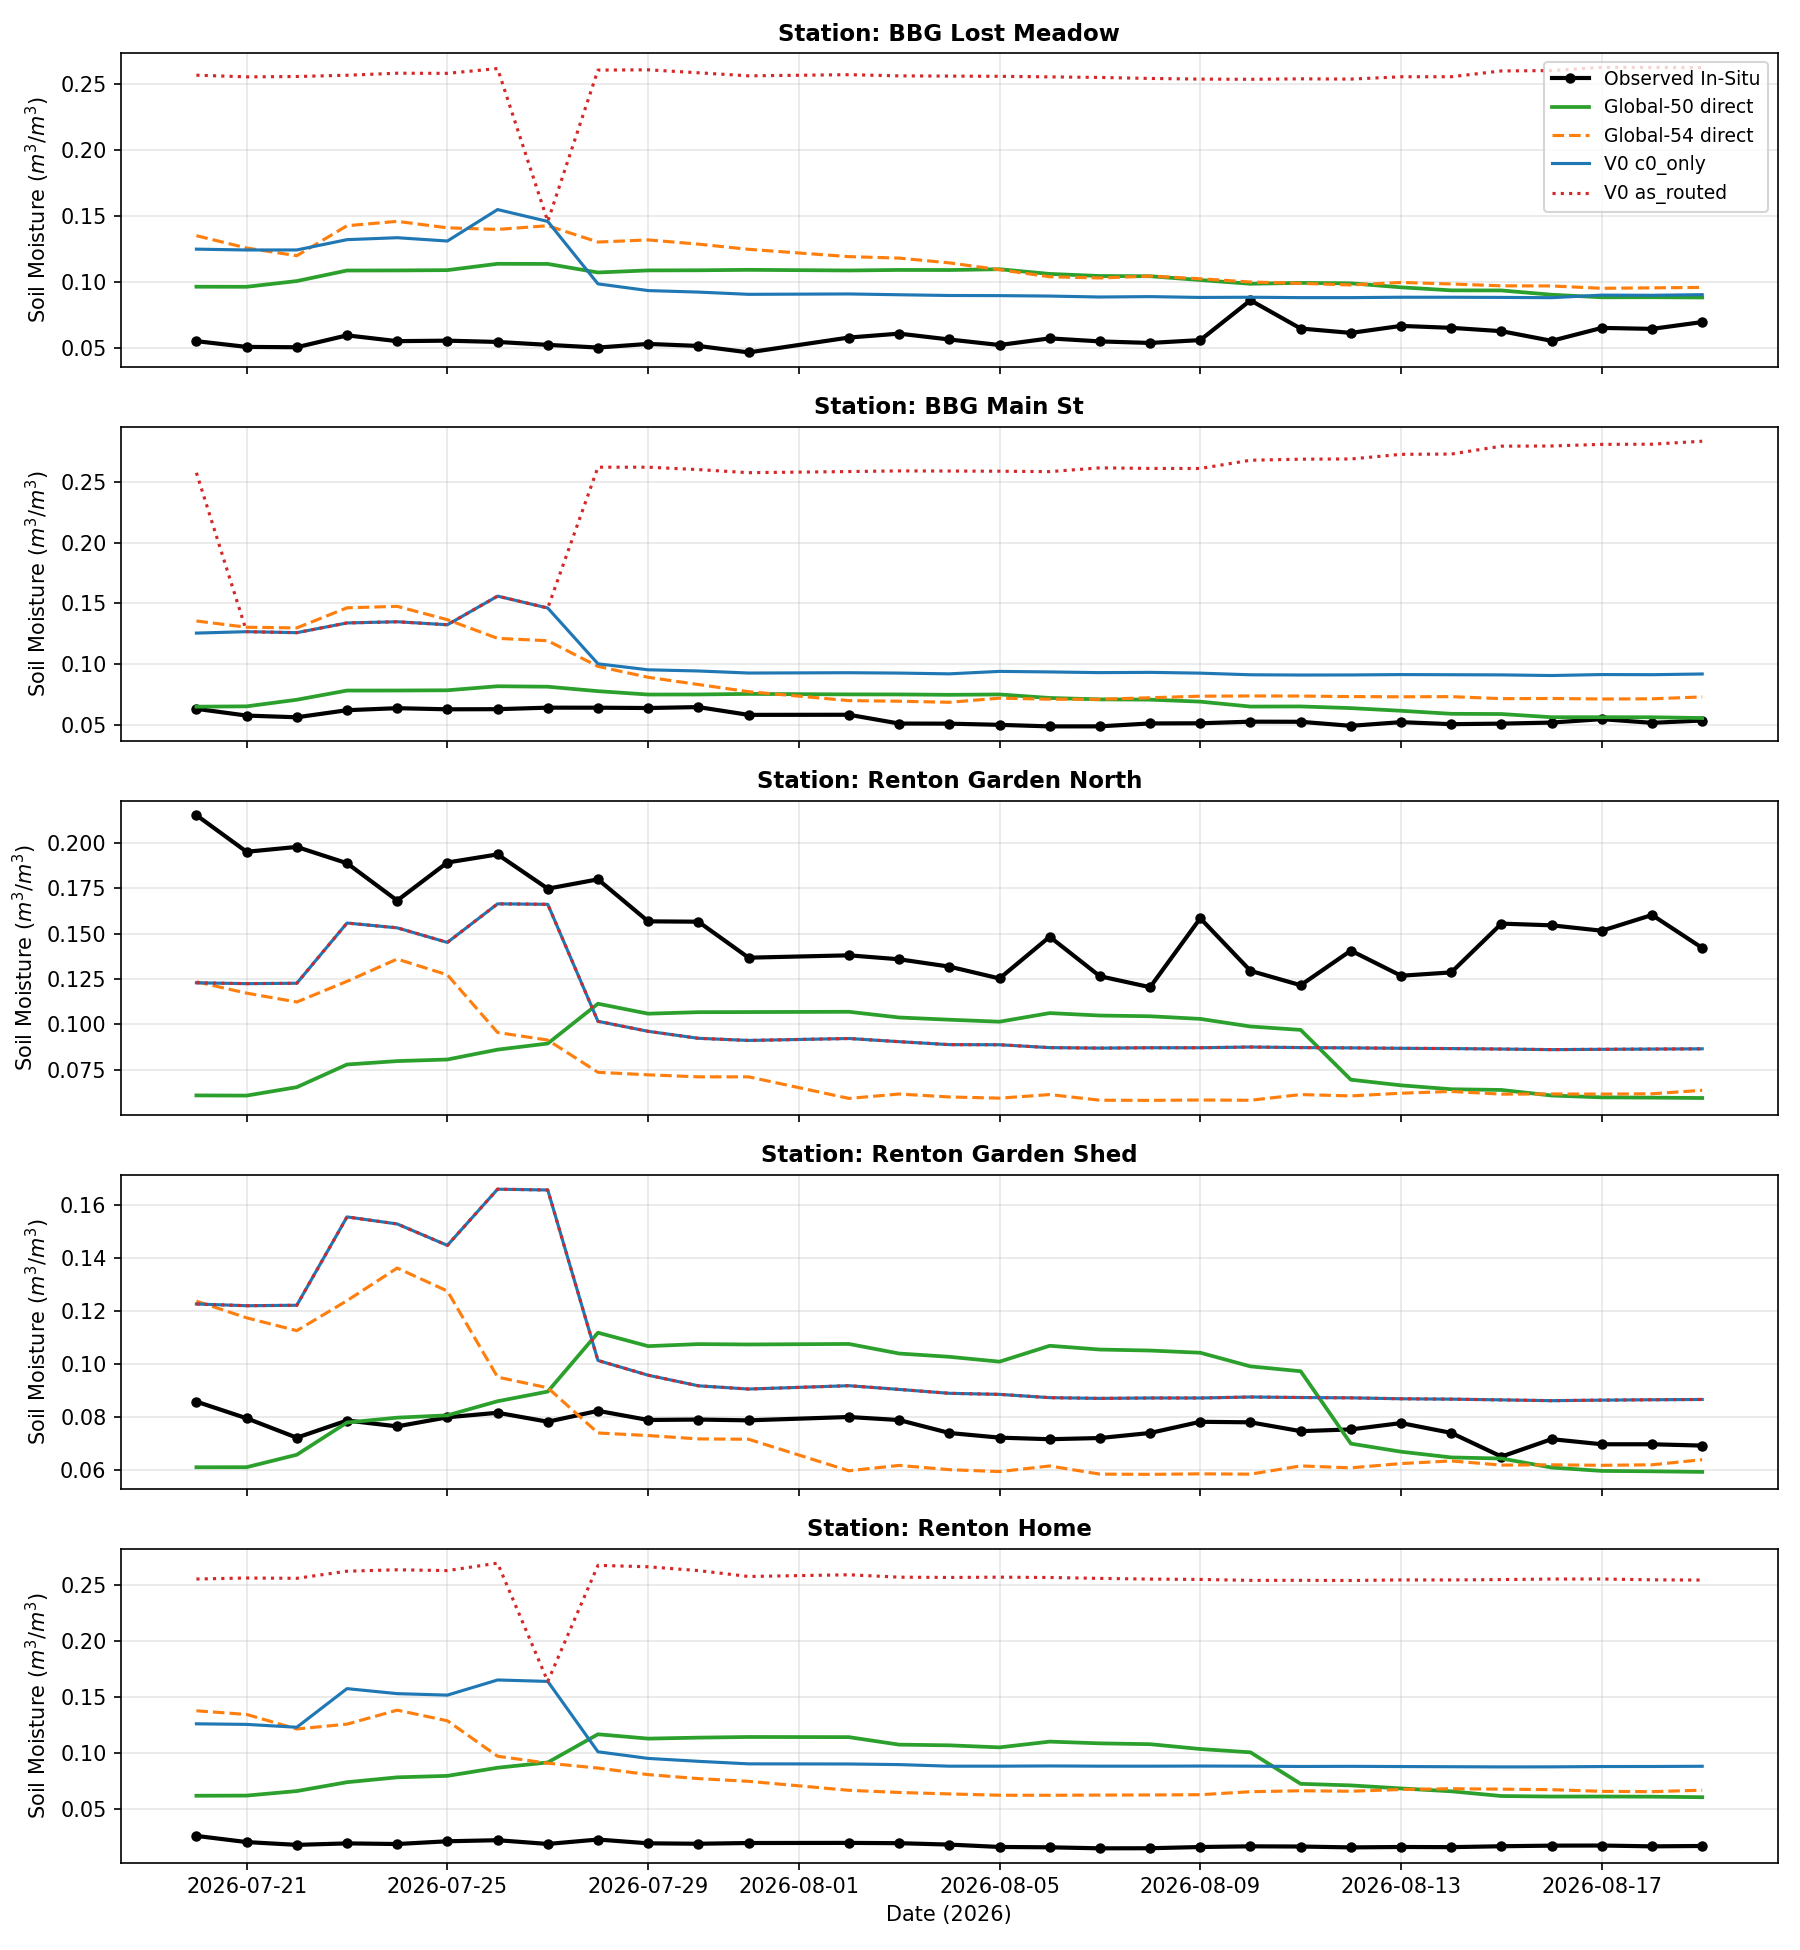

In [5]:
import importlib.util

PLOT_PATH = EXP_DIR / "plot_timeseries.py"
plot_spec = importlib.util.spec_from_file_location("salvage_plots", PLOT_PATH)
plots = importlib.util.module_from_spec(plot_spec)
plot_spec.loader.exec_module(plots)
plots.main([])

from IPython.display import Image, display
display(Image(str(EXP_DIR / "figures" / "timeseries_v3_baselines_overlay.png")))
